<h1>NAO RMSE - SPREAD - SATURATION</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)
    
from src.datareader import datareader as dr
from src.util import util, stats

import warnings
warnings.filterwarnings('ignore')

<h5>Get data readers</h5>

In [3]:
ufs_experiments = ['baseline', 'beta.0.1', 'c96_beta.0.1', 'cpc_ics']

ufs_data_readers = [dr.getDataReader(datasource='UFS',
                                     # filename=f'experiments/phase_1/{m}/atm_monthly.zarr',
                                     experiment = this_experiment,
                                     model='atm')
                    for this_experiment in ufs_experiments]

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr
No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/beta.0.1/atm_monthly.zarr
No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/c96_beta.0.1/atm_monthly.zarr
No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/cpc_ics/atm_monthly.zarr


In [4]:
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [5]:
ufs_vars = ['tmpsfc', 'tsfc']
era5_var = 'sea_surface_temperature'

<h5>Define time period</h5>

In [6]:
# time_range = ("1994-05-01", "2021-10-31T23")
# initmonths = (11,)

time_range = ("1994-05-01", "2021-04-30T23")
initmonths = (5,)

<h5>Define NAO locations</h5>

In [7]:
# For NAO, there are 2 reference locations:
region_1 = {'latmin': 65.0, 'lonmin': 331.2}
region_2 = {'latmin': 37.7, 'lonmin': 334.3}

<h5>Get climatology statistics for nino 3.4</h5>

In [8]:
# Enter a list of members, like [1, 2, 6, 8, ens_avg]
# Note that 'ens_avg' is a special keyword in the ensuing code.
# If you include 'ens_avg' in the list of members,
# then the Ensemble Average will be listed under member = -1
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'ens_avg']

<h5>Statistical accumulation will take a few minutes... please be patient.</h5>

In [9]:
%%capture captured_output

ufs_dss_1 = []
ufs_dss_2 = []
ufs_var_list = []
ufs_stats_1 = []
ufs_stats_2 = []

for this_dr in ufs_data_readers:
    
    for this_var in ufs_vars:                                                                                   
        if this_var in list(this_dr.dataset().keys()):                                                               
            ufs_var = this_var

    ufs_var_list.append(ufs_var)  # Keep track of which ufs variable name is used here.
    
    # Get datasets
    this_ds_1 = util.retrieve_ufs_dataset(this_dr, ufs_var, time_range, members, region_1, initmonths=initmonths)
    this_ds_2 = util.retrieve_ufs_dataset(this_dr, ufs_var, time_range, members, region_2, initmonths=initmonths)
    
    ufs_dss_1.append(this_ds_1.squeeze(['lat', 'lon']).load())  # flatten and load
    ufs_dss_2.append(this_ds_2.squeeze(['lat', 'lon']).load())  # flatten and load
    
    # Calculate climatology statistics
    ufs_stats_1.append(stats.calc_climatology_anomaly(ufs_dss_1[-1], area_mean=False))
    ufs_stats_2.append(stats.calc_climatology_anomaly(ufs_dss_2[-1], area_mean=False))

In [10]:
era5_ds_1 = era5_data_reader.retrieve(var=era5_var,
                lat=region_1['latmin'],
                lon=region_1['lonmin'],
                time=time_range).squeeze(['lat', 'lon']).load()  # flatten and load

era5_ds_2 = era5_data_reader.retrieve(var=era5_var,
                lat=region_2['latmin'],
                lon=region_2['lonmin'],
                time=time_range).squeeze(['lat', 'lon']).load()  # flatten and load

In [11]:
# ERA5 climatology statistics
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)

<h5>Normalize the data.  z = (X - mu) / sigma</h5>

In [12]:
# Normalize UFS datasets
ufs_das_1 = []
ufs_das_2 = []

for i in range(len(ufs_dss_1)):  
    ufs_das_1.append(stats.normalize(da=ufs_dss_1[i][ufs_var_list[i]], stats=ufs_stats_1[i]))
    ufs_das_2.append(stats.normalize(da=ufs_dss_2[i][ufs_var_list[i]], stats=ufs_stats_2[i]))

In [13]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)

<h2>Calculate NAO Index</h2>

<h5>Take difference between 2 locations and store result into new datasets</h5>

In [14]:
ufs_nao = []

for i in range(len(ufs_das_1)):
    ufs_nao.append((ufs_das_2[i] - ufs_das_1[i]).to_dataset())

In [15]:
era5_nao = (era5_da_2 - era5_da_1).to_dataset()

<h5>climatology</h5>

In [16]:
ufs_stats = []

for i in range(len(ufs_nao)):
    ufs_stats.append(stats.calc_climatology_anomaly(ufs_nao[i], area_mean=False, use_member_climatology=True))

In [17]:
era5_stats = stats.calc_climatology_anomaly(era5_nao, area_mean=False)

<h3>Accumulating RMSE and SPREAD statistics for each UFS model.  This may take some time!</h3>

In [18]:
# ufs_ds: xr.Dataset
# ufs_var: str
# ufs_stats: dict
# verif_ds: xr.Dataset
# erif_var: str
# verif_stats: dict

rmses = [stats.calc_rmse_spread(ufs_nao[i], ufs_var_list[i], ufs_stats[i], era5_nao, era5_var, era5_stats)
         for i in range(len(ufs_nao))]

Number of ensemble members: 11
Number of years: 27
Accumulating Statistics...
Finished.
Number of ensemble members: 11
Number of years: 27
Accumulating Statistics...
Finished.
Number of ensemble members: 11
Number of years: 27
Accumulating Statistics...
Finished.
Number of ensemble members: 11
Number of years: 27
Accumulating Statistics...
Finished.


<h2>Plot statistics</h2>

<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/ufs_py311/lib/python3.11/site-packages/matplotlib/pyplot.py'>

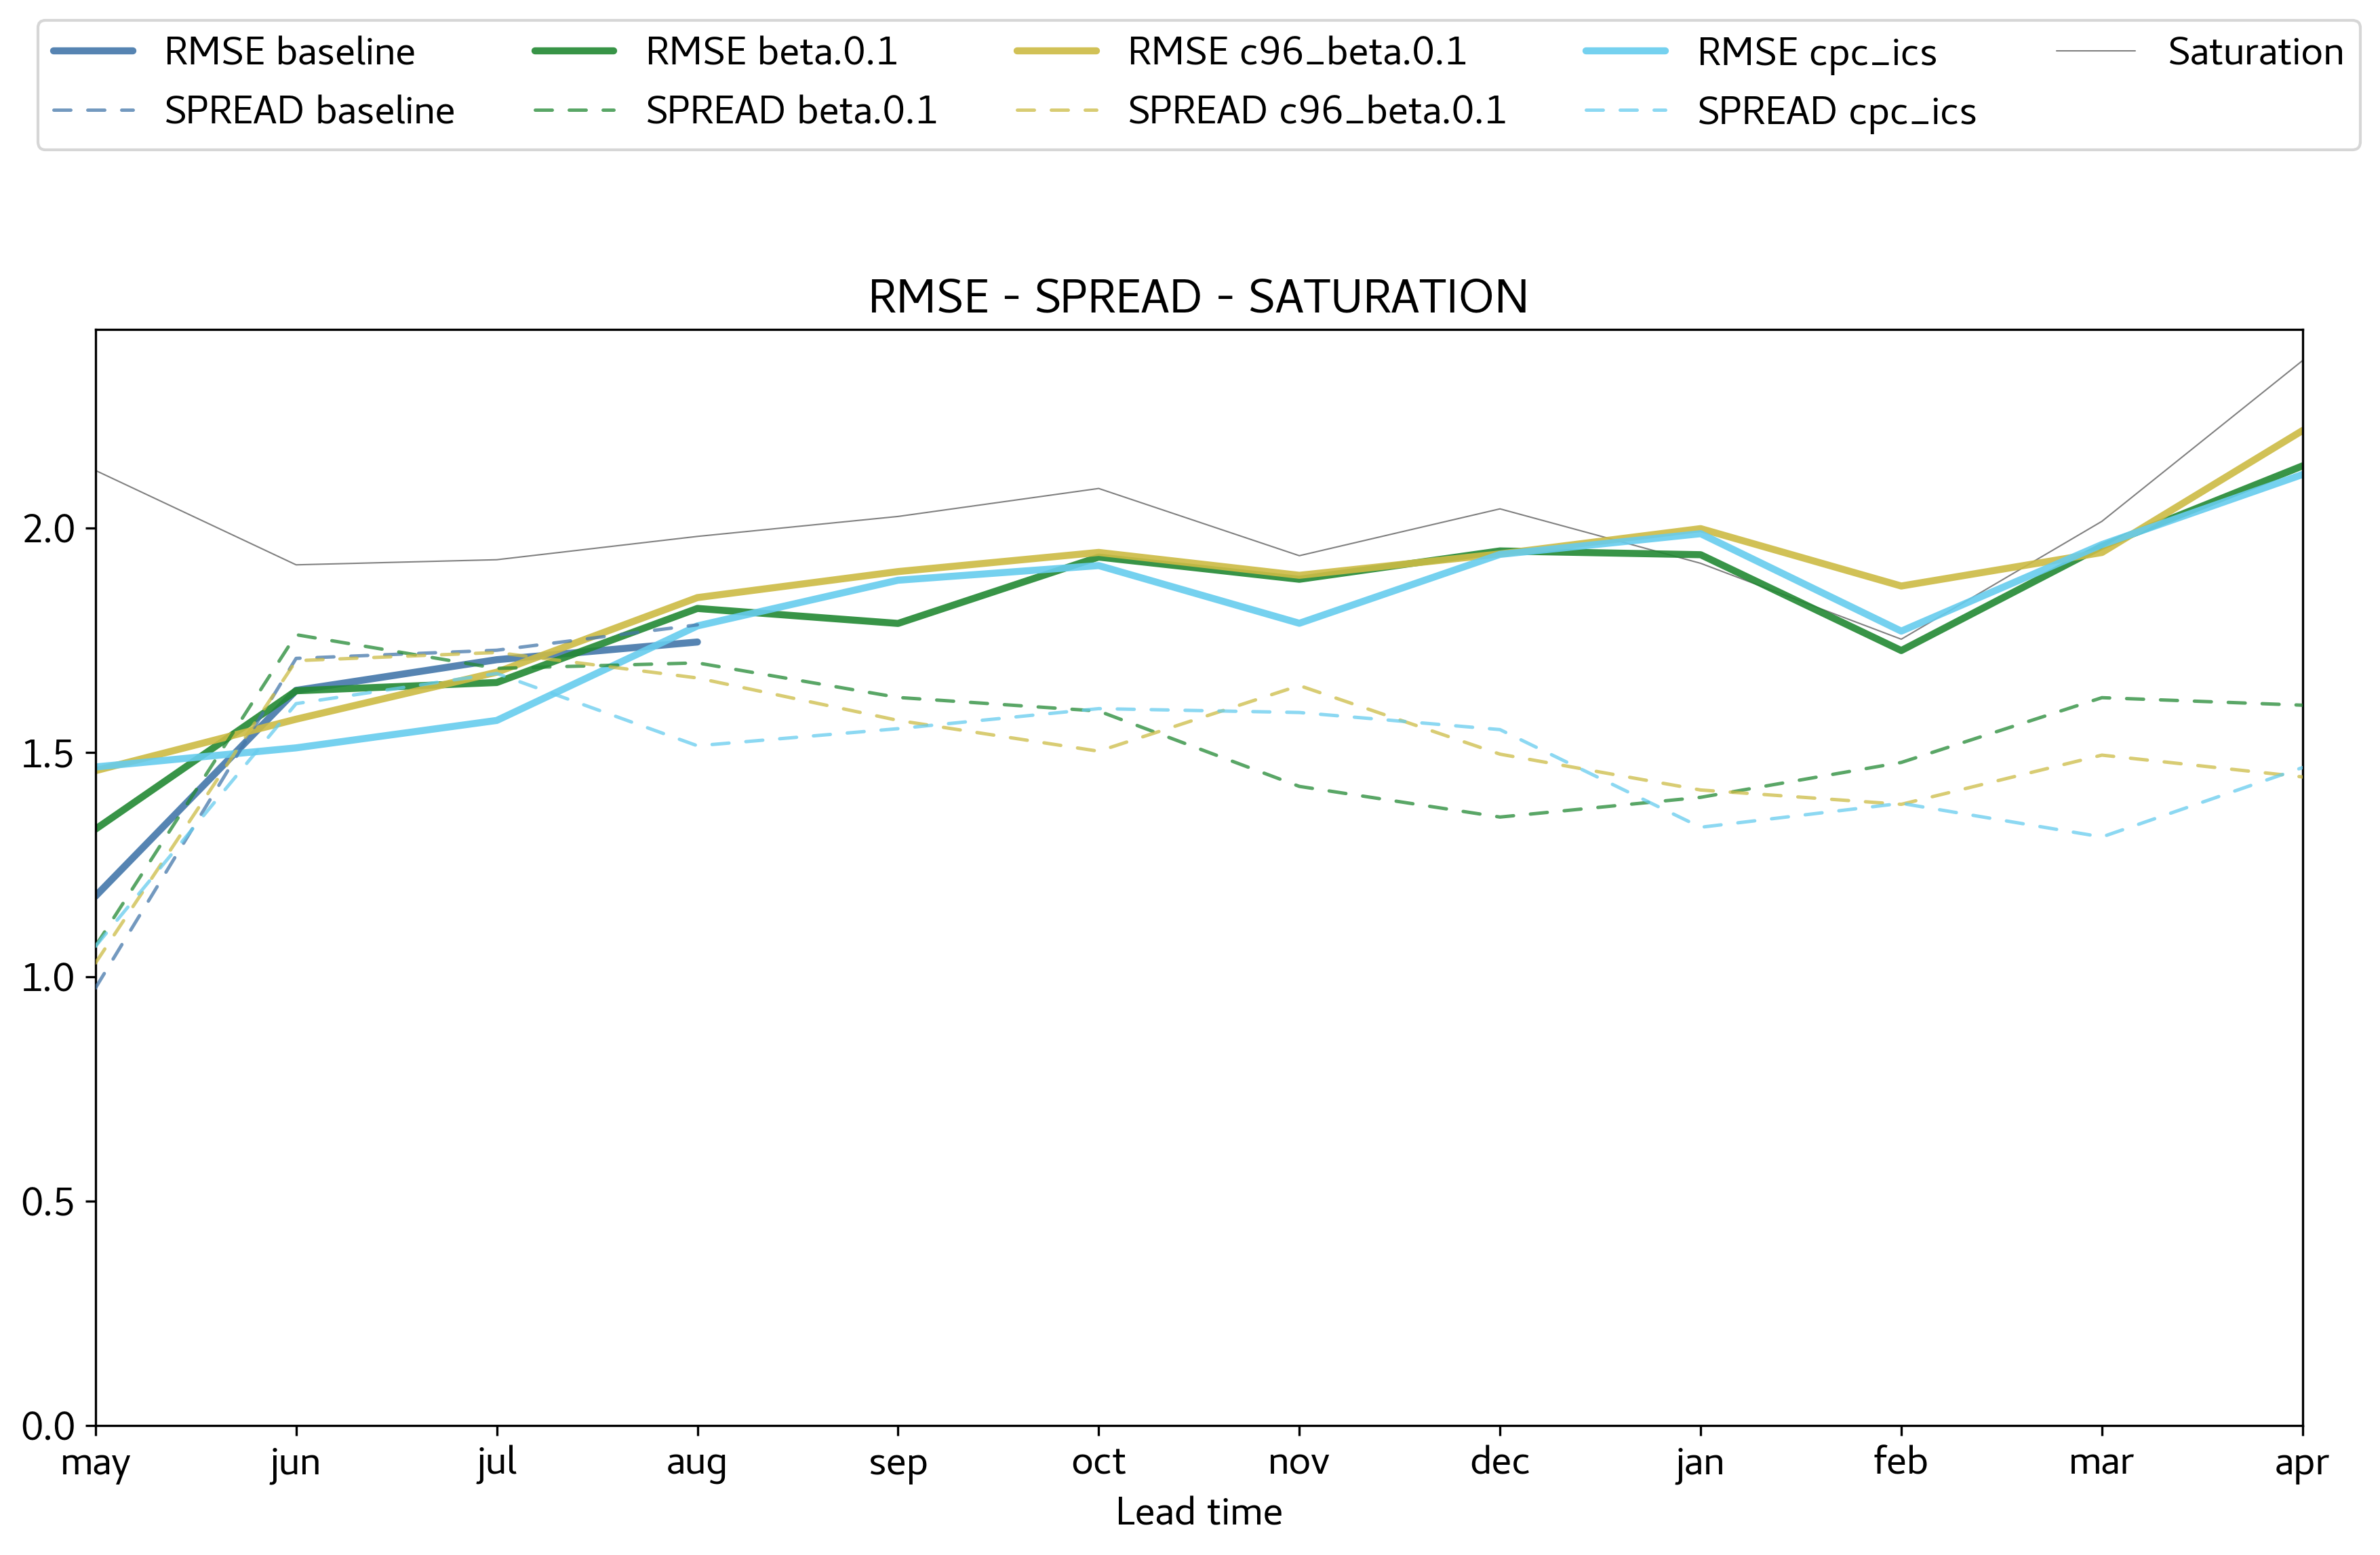

In [19]:
stats.plot_rmse_spread(rmses,
                       ufs_experiments,
                       rmse_only=False,
                       spread_only=False,
                       verif_stats=era5_stats,
                       title='RMSE - SPREAD - SATURATION',
                       dpi=300)